In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame(pd.read_csv('./.data/train/Slip/Trip/Session_8_rel_time.csv'))
false_fall_df = pd.DataFrame(pd.read_csv('.data/train/notFall/False_labeled_Session1.csv'))

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7024 entries, 0 to 7023
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sensor_1  7024 non-null   int64  
 1   sensor_2  7024 non-null   int64  
 2   sensor_3  7024 non-null   int64  
 3   sensor_4  7024 non-null   int64  
 4   time_sec  7024 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 274.5 KB


In [4]:
df.isna().sum()

sensor_1    0
sensor_2    0
sensor_3    0
sensor_4    0
time_sec    0
dtype: int64

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np

In [7]:
def pick_2d(spec_like):
    """Accept [array], array, (1,F,T), (F,T,1), (C,F,T), etc. → return 2D (F, T)."""
    arr = spec_like[0] if isinstance(spec_like, (list, tuple)) else np.asarray(spec_like)
    # Squeeze singleton dims
    if arr.ndim >= 3 and 1 in arr.shape:
        arr = np.squeeze(arr)
    if arr.ndim == 3:         # pick first channel if still 3D
        arr = arr[0]
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D spectrogram after squeezing, got {arr.shape}")
    # Heuristic: freq bins are usually fewer than time frames
    F, T = arr.shape
    if F > T:
        arr = arr.T  # ensure (F, T)
    return arr  # (F, T), linear PSD

def power_to_db(power, ref=1.0, floor_db=-100.0, eps=1e-18):
    """Linear PSD → dB re `ref` (default 1 unit²/Hz)."""
    db = 10.0 * np.log10(np.maximum(power, eps) / ref)
    return np.maximum(db, floor_db)

def _unit_label(unit: str, scale: str):
    # For colorbar label
    if scale == "linear":
        return f"{unit}^2/Hz"
    # dB
    return f"dB re 1 {unit}^2/Hz"

def plot_vibration_spectrogram(
    spec_like,
    *,
    fs=200,           # sampling rate [Hz] → for axis in seconds/Hz (optional)
    hop=64,          # hop size [samples] (optional)
    nperseg=256,      # window length → for freq bins (optional; improves extent)
    unit="g",          # "g" or "m/s^2" (use whatever your PSD unit is)
    scale="dB",        # "dB" or "linear"
    db_floor=-1.0,
    title=None,
    fmax=None          # optionally cap visible frequency (Hz)
):
    S = pick_2d(spec_like)  # (F, T), linear PSD in unit^2/Hz
    F, T = S.shape

    # Convert to dB if requested
    if scale.lower() == "db":
        S_plot = power_to_db(S, ref=1.0, floor_db=db_floor)
    else:
        S_plot = S

    # Build axes if fs/hop provided; else fall back to frames/bins
    extent = None
    if fs is not None and hop is not None:
        # Frequency vector (best with nperseg; else infer from F)
        if nperseg is None:
            # F should equal nfft//2 + 1 → infer nperseg roughly
            nperseg = (F - 1) * 2
        freqs = np.fft.rfftfreq(nperseg, d=1.0/fs)
        # Map vertical bins to these centers
        # If freqs length mismatches slightly, just limit to min length
        m = min(len(freqs), F)
        freqs = freqs[:m]
        S_plot = S_plot[:m, :]
        # Time axis from hop
        times = np.arange(T) * (hop / fs)
        extent = [times[0], times[-1] + hop / fs, freqs[0], freqs[-1]]

    # Apply frequency cap for visualization if requested
    if fmax is not None and extent is not None:
        # Compute row index for fmax
        f0, f1 = extent[2], extent[3]
        if fmax < f1:
            frac = (fmax - f0) / (f1 - f0)
            rows = int(max(1, np.floor(frac * S_plot.shape[0])))
            S_plot = S_plot[:rows, :]
            extent[3] = fmax

    # Titles and labels
    if title is None:
        base = "Acceleration PSD Spectrogram"
        title = base + (" (dB)" if scale.lower() == "db" else " (linear)")

    plt.figure(figsize=(8, 4))
    im = plt.imshow(
        S_plot,
        origin="lower",
        aspect="auto",
        extent=extent  # None → frames/bins; else seconds/Hz
    )
    cbar = plt.colorbar(im)
    cbar.set_label(_unit_label(unit, scale=scale.lower()))
    plt.xlabel("Time (s)" if extent is not None else "Time (frames)")
    plt.ylabel("Frequency (Hz)" if extent is not None else "Frequency (bins)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [3]:
df.head()

,sensor_1,sensor_2,sensor_3,sensor_4,time_sec
0,1945,1882,1942,2018,0.000000
1,1936,1857,1956,2026,0.000213
2,1871,1907,1938,1985,0.000398
3,1889,1982,1902,1872,0.000580
4,1919,2002,1889,1791,0.000759


In [7]:
df["time_sec"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9817 entries, 0 to 9816
Series name: time_sec
Non-Null Count  Dtype  
--------------  -----  
9817 non-null   float64
dtypes: float64(1)
memory usage: 76.8 KB


In [5]:
len(df)

9817

In [6]:
df["time_sec"].max()

np.float64(47.083167)

In [18]:
event = df[["sensor_1", "sensor_2", "sensor_3"]].max()

In [23]:
df[df["sensor_1"] == event["sensor_1"]]

,sensor_1,sensor_2,sensor_3,sensor_4,time_sec
3771,4095,4095,2683,4095,16.859237
3772,4095,3573,2531,3969,16.864218
3785,4095,4095,2534,4095,16.929223
3795,4095,3679,2459,4095,16.979182
3796,4095,4081,2737,4095,16.983827
3797,4095,4095,2879,4095,16.989213
3798,4095,3728,2839,4095,16.994199


In [25]:
df[df["sensor_1"] == df["sensor_1"].max()]["time_sec"].max()

np.float64(16.994199)

In [11]:
ts = df[df["time_sec"] > 6.55]["sensor_1"]

In [16]:
ts[1710]

np.int64(1959)

In [5]:
df["sensor_1"].min()

np.int64(0)

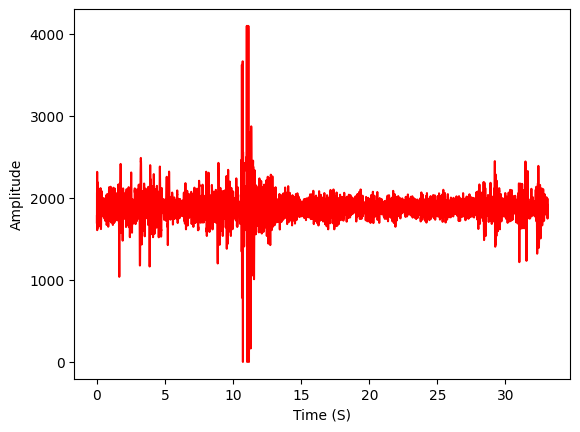

In [21]:
plt.plot(df["time_sec"], df["sensor_1"], color='red')
plt.xlabel("Time (S)"),
plt.ylabel("Amplitude")
plt.show()

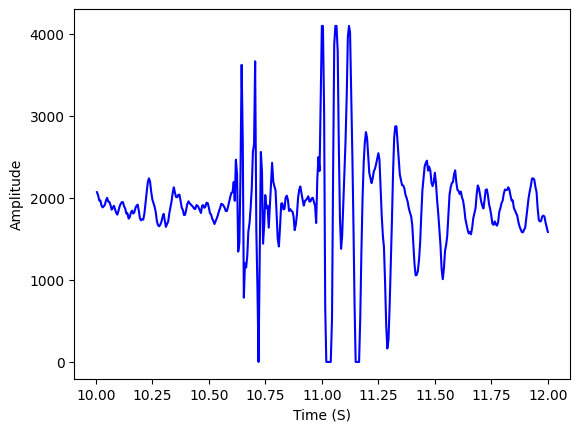

In [19]:
plt.plot(df[(df["time_sec"] >= 10) & (df["time_sec"] <= 12)]["time_sec"], df[(df["time_sec"] >= 10) & (df["time_sec"] <= 12)]["sensor_1"], color='blue')
plt.xlabel("Time (S)"),
plt.ylabel("Amplitude")
plt.show()